# Laborator 11 -> Football

Se cere identificarea comunităților existente într-o rețea folosind:
- un algoritm predefinit intr-o biblioteca specializata (e.g. networkx, gephi, altele);
- un algoritm evolutiv.

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from networkx.linalg.graphmatrix import adjacency_matrix
from pyvis.network import Network

### Vizualizarea retelei

In setul de date initial exista muchii care se repeta. Drept solutie, il vom considera multigraf la citire si il vom tranforma in graf simplu dupa citire.

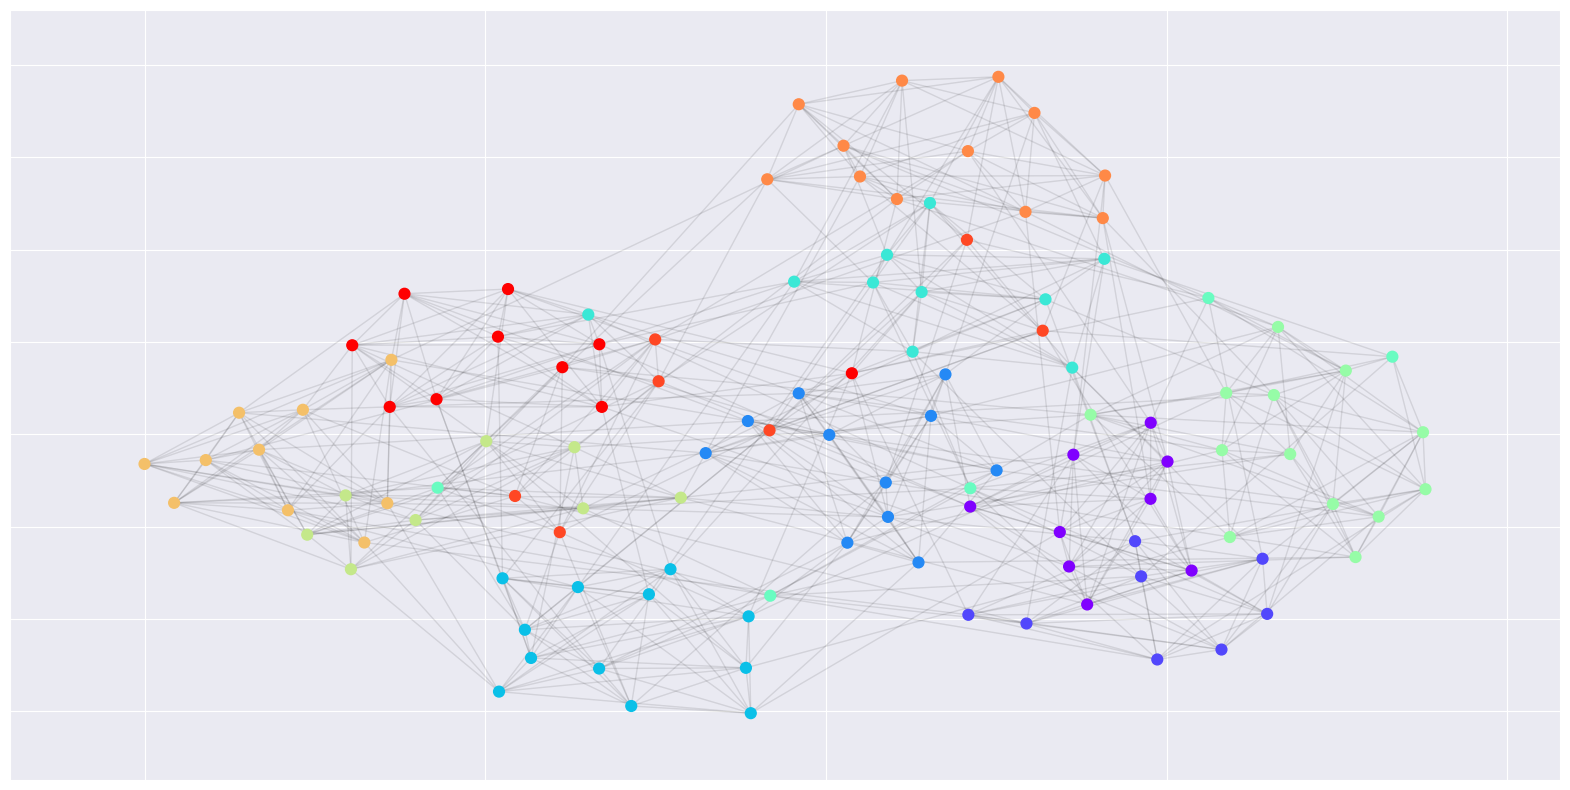

In [18]:
# graful care descrie reteaua
GMulti = nx.read_gml("../../given_networks/football/football.gml")
# transforma multigraful in graf simplu
G = nx.Graph(GMulti)

labelList = list(G.nodes())
adjacencyMatrix = nx.to_numpy_array(G).tolist()
adjacencyMatrix = [[int(x) for x in row] for row in adjacencyMatrix]

communities = [0] * len(labelList)

# se salveaza apartenenta fiecarui nod la o comunitate
with open("../../given_networks/football/classLabelfootball.txt", "r") as f:
    for linie in f:
        date = linie.strip().split()
        if len(date) == 2:
            id_text = int(date[0])
            community = int(date[1])

            name = labelList[id_text-1]
            G.nodes[name]["group"] = community
            communities[id_text-1] = community

dataCommunities = []

with open("../../given_networks/football/real.dat", "r") as f:
    for linie in f:
        nodes = [int(x) for x in linie.strip().split()]
        dataCommunities.append(nodes)

pos = nx.spring_layout(G,seed = 23)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea conform celor 3 functii de fitness: modularity, conductance si community score

In [19]:
def modularity(communities, adjacencyMatrix,differentiaryFactor):
    m = sum(sum(row) for row in adjacencyMatrix) / 2
    Q = 0
    for community in communities:
        for i in community:
            for j in community:
                # nodurile sunt numerotate de la 1, dar in matrice sunt stocate incepand cu pozitia 0 (caz in care differentiaryFactor este 1 -> pentru cod propriu, nu va exista aceasta diferenta)
                ki = sum(adjacencyMatrix[i-differentiaryFactor])
                kj = sum(adjacencyMatrix[j-differentiaryFactor])

                Q += adjacencyMatrix[i-differentiaryFactor][j-differentiaryFactor] - ki * kj / (2 * m)

    Q *= 1/(2*m)
    return Q

In [20]:
def conductance(communities, adjacencyMatrix,differentiaryFactor):
    # CONDUCTANCE: 1/k * sum(c(i))
    # c(i) = cut(c,c_)/min(vol(c),vol(c_))
    # vol(c) -> suma tuturor gradelor nodurilor din interiorul comunitatii

    Q = 0

    overallSum = 0
    for community in communities:
        for node in community:
            overallSum += sum(adjacencyMatrix[node - differentiaryFactor])

    for community in communities:
        outsiders = 0
        summ = 0
        for i in community:
            for neighbour,value in enumerate(adjacencyMatrix[i-differentiaryFactor]):
                if value != 0:
                    if neighbour not in community:
                        outsiders += 1
                    summ += 1

        if min(summ, overallSum - summ) == 0:
            continue

        Q+= outsiders/ min(summ,overallSum - summ)

    Q /= len(communities)
    return Q

In [21]:
def communityScore(communities, adjacencyMatrix,differentiaryFactor):
    # COMMUNITY SCORE: 1/k * sum(f(i))
    # f(i) = m_in / (m_in + m_out)^alpha
    # m_in -> nr de muchii complet cuprinse in comunitatea curenta
    # m_out -> nr de muchii care au EXACT o extremitate in comunitatea curenta
    # alpha -> controleaza penalitatea pe care o primeste o comunitate atunci cand are muchii "exterioare"

    Q = 0
    alpha = 0.5

    for community in communities:
        # m_out
        outsiders = 0

        # m_in
        insiders = 0

        for i in community:
            for neighbour,value in enumerate(adjacencyMatrix[i - differentiaryFactor]):
                if value != 0:
                    if neighbour not in community:
                        outsiders += 1
                    else:
                        insiders += 1

        # deoarece este vorba de muchii interne, acestea se vor numara de doua ori: de fiecare data, in cadrul calculului pentru cate o extremitate
        insiders = insiders//2
        total_edges = outsiders + insiders

        if total_edges > 0:
            Q += insiders / (total_edges ** alpha)

    Q /= len(communities)
    return Q

In [22]:
print(modularity(dataCommunities, adjacencyMatrix,1))
print(conductance(dataCommunities, adjacencyMatrix,1))
print(communityScore(dataCommunities, adjacencyMatrix,1))

0.5539733187144178
0.896469277003773
0.5043800935589373


### Determinarea comunitatilor cu tool

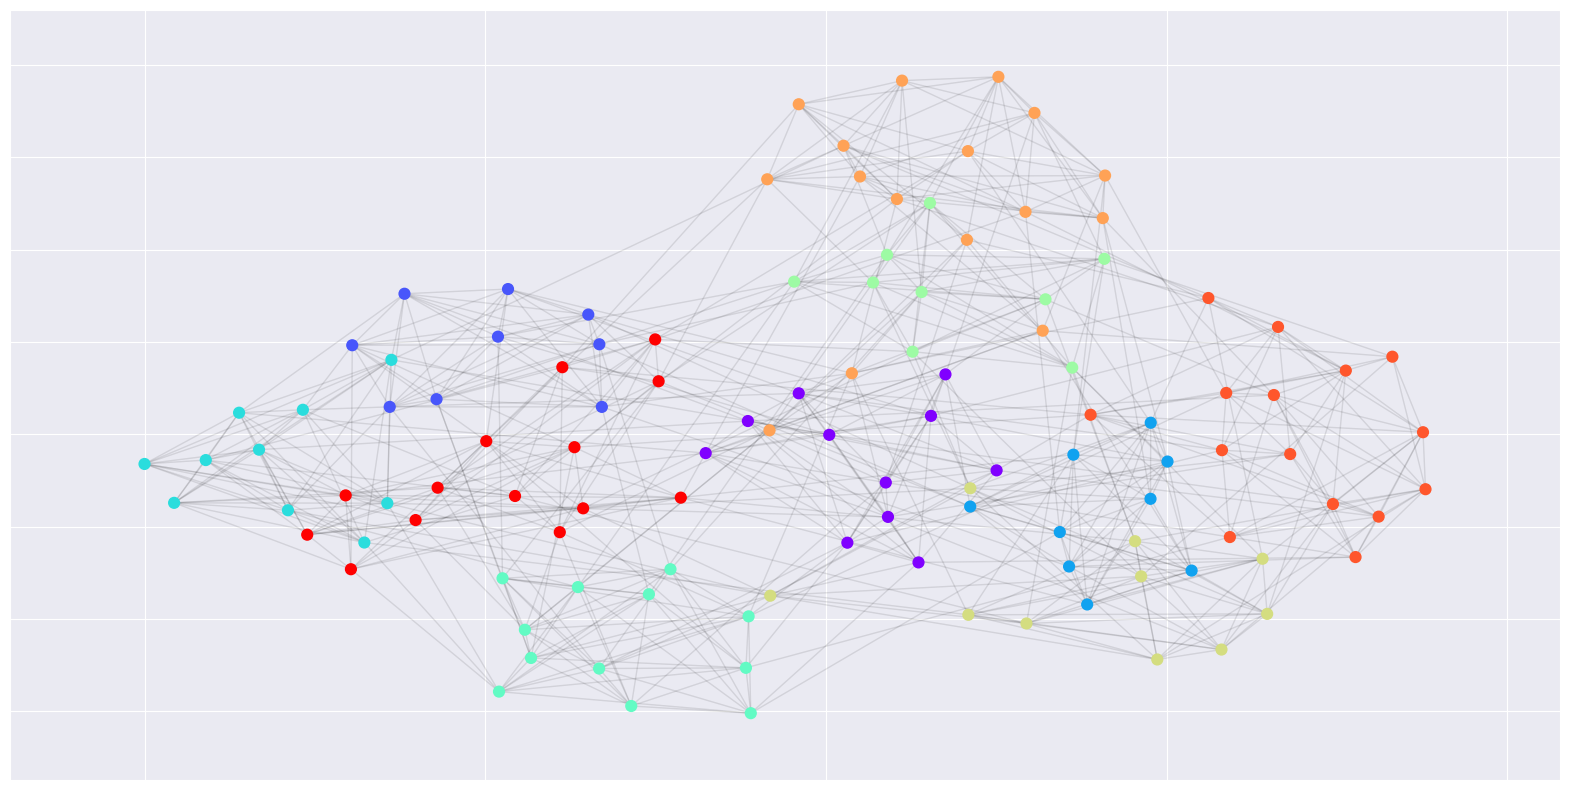

In [23]:
from networkx.algorithms import community

# se introduce si param seed, deoarece, in cadrul algoritmului exista acea comp. aleatorie
# se vor returna seturi (comunitatile) ce contin id-urile
communityTOOL = community.louvain_communities(G, seed=11)

# reprezentarea numerica
nameToId = {name: idx for idx, name in enumerate(G.nodes())}
communityTOOLNumerical = []

for nodeSet in communityTOOL:
    # se transforma fiecare nume in id-ul sau
    currentCommunity = [nameToId[nodeName] for nodeName in nodeSet]
    communityTOOLNumerical.append(currentCommunity)

communities = [0] * len(labelList)
for idComunity, com in enumerate(communityTOOLNumerical):
    for nod in com:
        #G.nodes[nod]['group'] = idComunity
        communities[nod] = idComunity

pos = nx.spring_layout(G,seed = 23)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [24]:
print(modularity(communityTOOLNumerical, adjacencyMatrix,0))

0.6045695626834523


### Determinarea comunitatilor folosind cod propriu

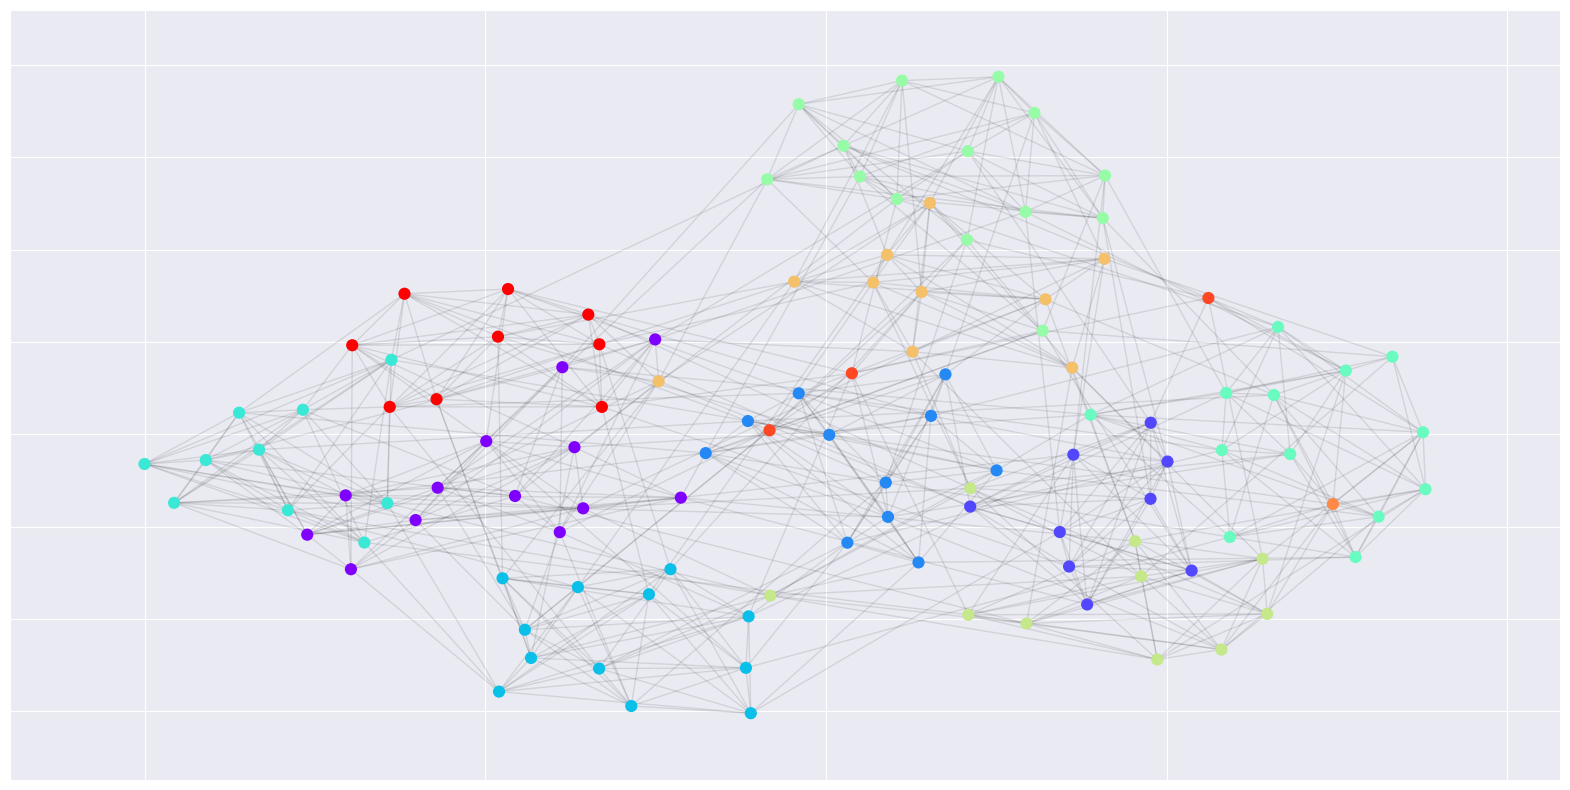

In [25]:
from fitnessModularity import fitnessFunction
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.1
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
nodesList = list(G.nodes())
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        nodeName = nodesList[nodeIndex]
        G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId


pos = nx.spring_layout(G,seed = 23)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [26]:
print(modularity(decodedBest, adjacencyMatrix,0))

0.580816938065668


### Cod propriu -> Conductance Fitness Function

Se trateaza cazul in care este utilizata, drept functie de fitness, conductance. Aceasta se bazeaza pe minimizarea nr de muchii care leaga mai multe comunitati (nu fac parte dintr-o singura comunitate).

Cu ce este util?
Deteacteaza mai bine decat functia de modularitate comunitatile mici (nu are acel bias prezent la functia de modularitate cu privire la dimensiunea comunitatii).

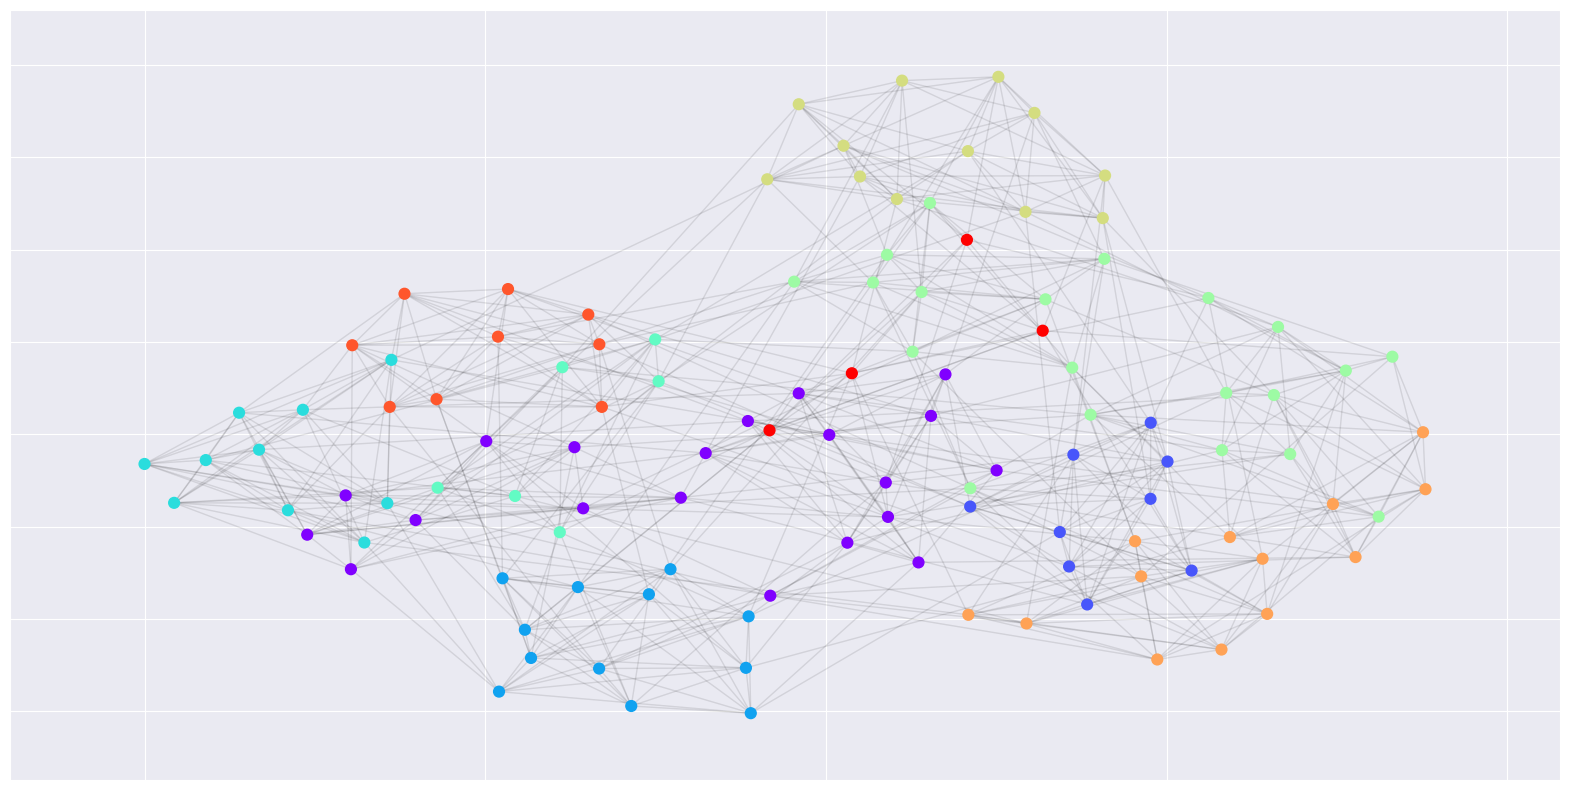

In [27]:
import fitnessConductance
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessConductance.fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.1
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        #nodeName = nodesList[nodeIndex]
        #G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId


pos = nx.spring_layout(G,seed = 23)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei pt Conductance

Cum se interpreteaza rezultatul:
- 0: comunitate perfecta
- <= 0.3: good communities
- <= 0.6: weak communities
- 1: poor partition

In [28]:
print(conductance(decodedBest, adjacencyMatrix,0))

0.3587462138055301


### Cod propriu -> Community Score Fitness Function

Se trateaza cazul in care este utilizata, drept functie de fitness, community score. In cadrul acestei abordari, accentul este pus pe nr de muchii interne ale unei comunitati.

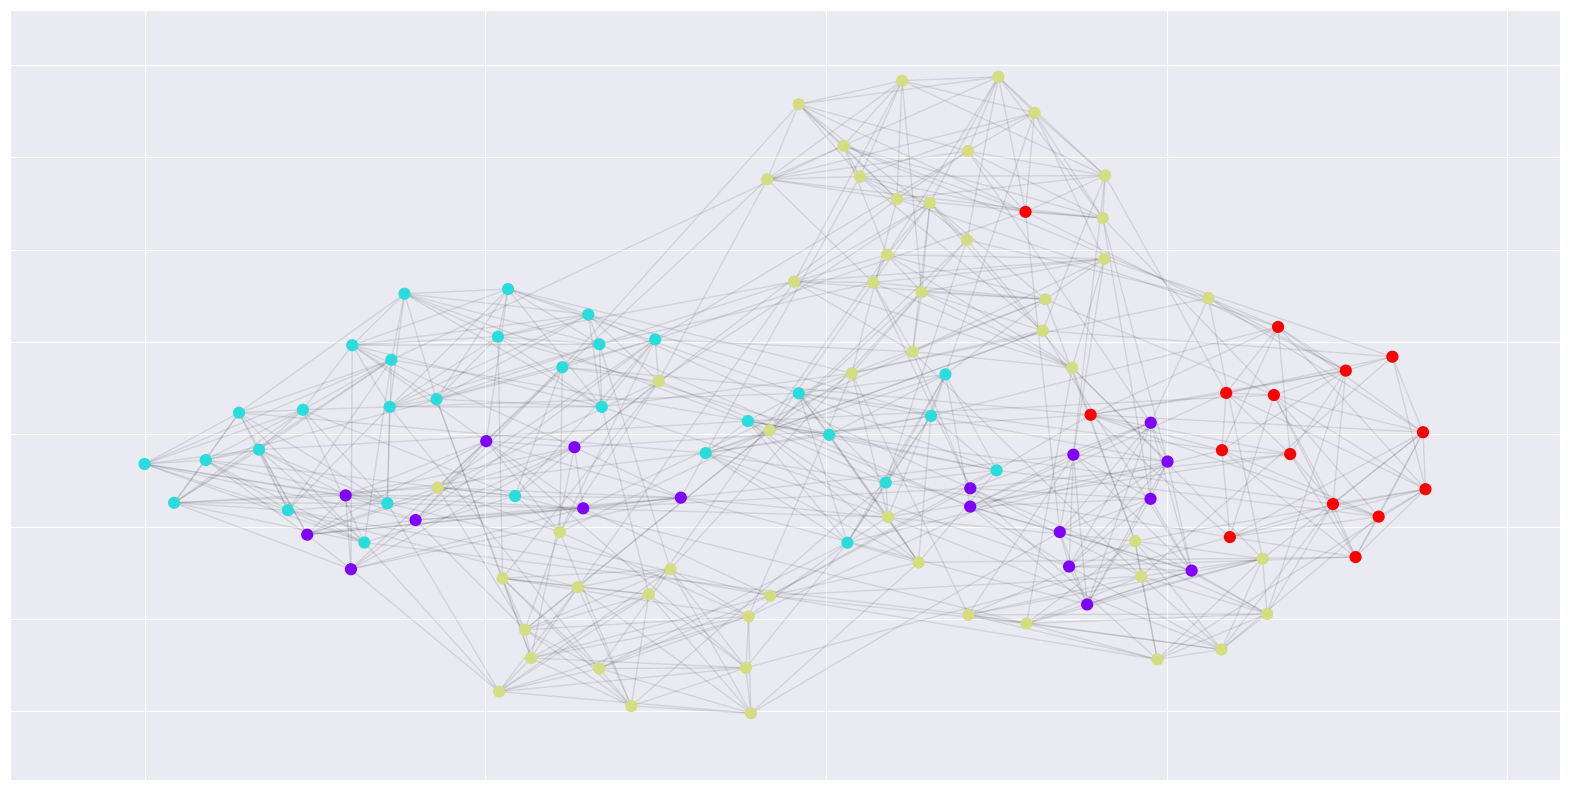

In [29]:
import fitnessCommunityScore
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessCommunityScore.fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.1
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        #nodeName = nodesList[nodeIndex]
        #G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId


pos = nx.spring_layout(G,seed = 23)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei pt Community Score

In [30]:
print(communityScore(decodedBest, adjacencyMatrix,0))

7.942397492507493
